# 02: Demographic & Economic Profile — DC

**Goal:** Washington DC demographic snapshot from Census ACS data.

**Data:** Census ACS 2023 — 1 record (DC only). **Limited dataset** — single-jurisdiction snapshot, not a comparative analysis.
**Source:** https://data.census.gov

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Load Data

In [2]:
df = pd.read_csv('../data/census_dc.csv')

print(f"Records: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Records: 1
Columns: ['name', 'population', 'median_income', 'state', 'pct_bachelors_plus', 'poverty_rate']


,name,population,median_income,state,pct_bachelors_plus,poverty_rate
0,District of Columbia,670587,101722,11,25.8,15.1


## DC Key Demographics

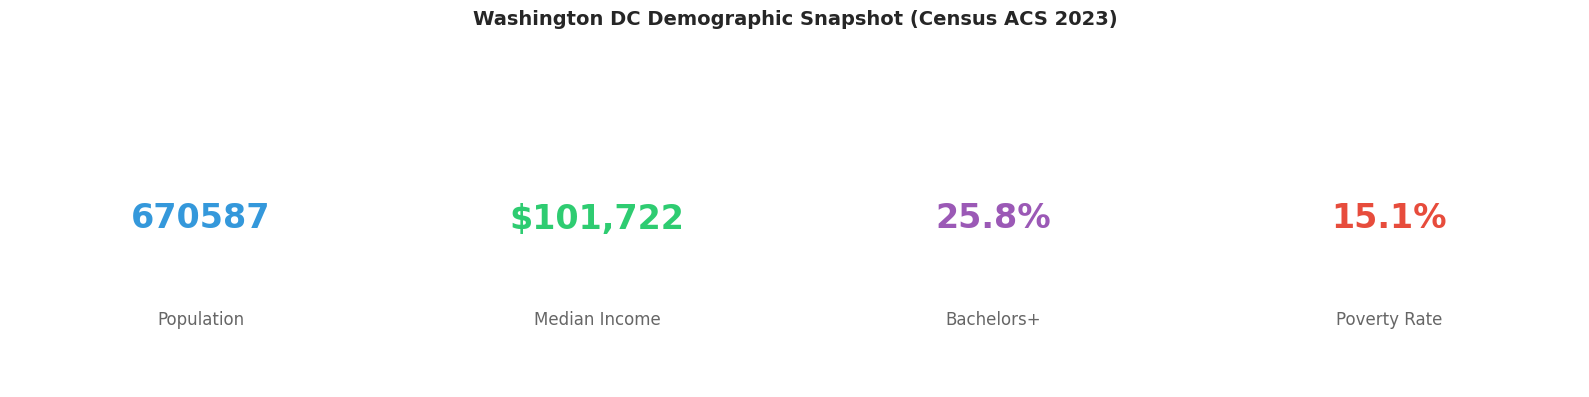

In [3]:
# Create a summary card visualization
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

metrics = [
    ('Population', df['population'].iloc[0] if 'population' in df.columns else 0, '#3498db'),
    ('Median Income', f"${df['median_income'].iloc[0]:,}" if 'median_income' in df.columns else 'N/A', '#2ecc71'),
    ('Bachelors+', f"{df['pct_bachelors_plus'].iloc[0]}%" if 'pct_bachelors_plus' in df.columns else 'N/A', '#9b59b6'),
    ('Poverty Rate', f"{df['poverty_rate'].iloc[0]}%" if 'poverty_rate' in df.columns else 'N/A', '#e74c3c'),
]

for ax, (label, value, color) in zip(axes, metrics):
    ax.text(0.5, 0.5, str(value), fontsize=24, ha='center', va='center', color=color, fontweight='bold')
    ax.text(0.5, 0.2, label, fontsize=12, ha='center', va='center', color='#666')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

fig.suptitle('Washington DC Demographic Snapshot (Census ACS 2023)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## DC Agency Performance

In [4]:
dc = pd.read_csv('../data/dc_agency_metrics.csv')
print(f"DC Agency Metrics: {len(dc)} records")
print(f"Agencies: {dc['agency_name'].nunique()}")
print(f"Metrics: {dc['metric_name'].unique().tolist()}")
dc.head()

DC Agency Metrics: 10 records
Agencies: 10
Metrics: ['Composite Performance Index']


,agency_name,metric_name,value,reporting_period,_source
0,Department of Health,Composite Performance Index,68,2024-Q1,labeled_sample_fallback
1,Metropolitan Police Department,Composite Performance Index,72,2024-Q1,labeled_sample_fallback
2,Department of Transportation,Composite Performance Index,58,2024-Q1,labeled_sample_fallback
3,Department of Energy & Environment,Composite Performance Index,80,2024-Q1,labeled_sample_fallback
4,Office of the Chief Technology Officer,Composite Performance Index,85,2024-Q1,labeled_sample_fallback


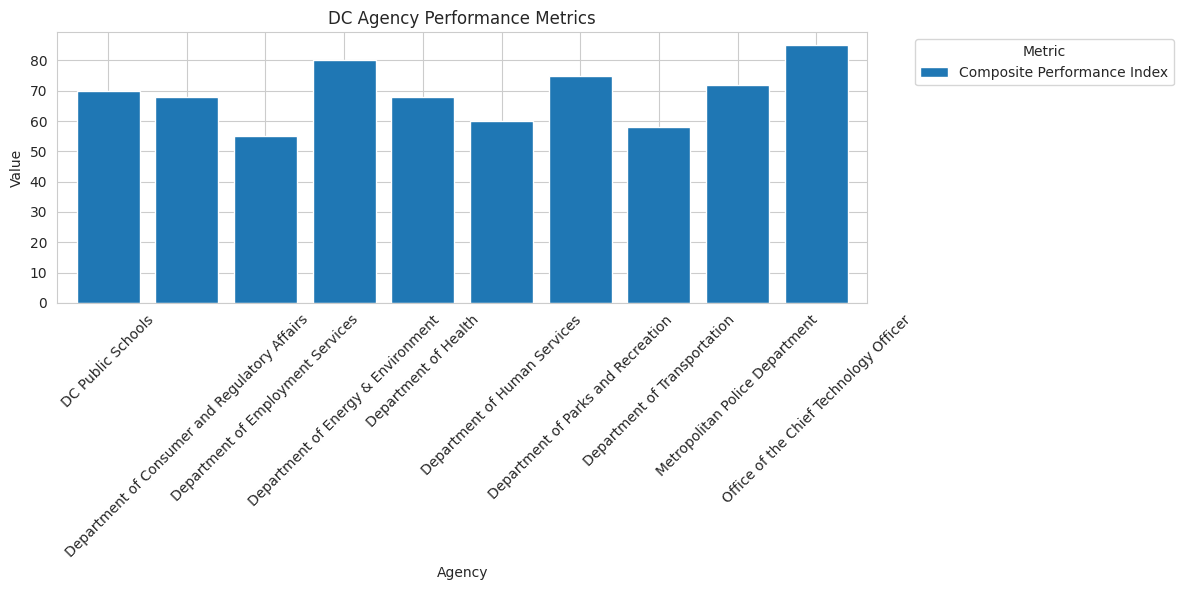

In [5]:
# Plot agency metrics
fig, ax = plt.subplots(figsize=(12, 6))
dc_pivot = dc.pivot_table(index='agency_name', columns='metric_name', values='value', aggfunc='first')
dc_pivot.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('DC Agency Performance Metrics')
ax.set_xlabel('Agency')
ax.set_ylabel('Value')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()